#Customer Segmentation of Credit Card Users Using Machine Learning

In this project, I use machine learning clustering algorithms to analyze the spending behavior of credit card users. By applying algorithms such as Hierarchical Clustering, I segment customers based on transaction patterns, purchase frequency, cash advances, and credit usage. The resulting clusters reveal distinct customer groups, providing insights for better risk assessment and targeted financial strategies.

# About Data

CUST_ID : Identification of Credit Card holder (Categorical)

BALANCE : Balance amount left in their account to make purchases (
BALANCE_FREQUENCY : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)

PURCHASES : Amount of purchases made from account

ONEOFF_PURCHASES : Maximum purchase amount done in one-go

INSTALLMENTS_PURCHASES : Amount of purchase done in installment

CASH_ADVANCE : Cash in advance given by the user

PURCHASES_FREQUENCY : How frequently the Purchases are being made, score
between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)

ONEOFFPURCHASESFREQUENCY : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)

PURCHASESINSTALLMENTSFREQUENCY : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)

CASHADVANCEFREQUENCY : How frequently the cash in advance being paid

CASHADVANCETRX : Number of Transactions made with "Cash in Advanced"
PURCHASES_TRX : Numbe of purchase transactions made

CREDIT_LIMIT : Limit of Credit Card for user

PAYMENTS : Amount of Payment done by user

MINIMUM_PAYMENTS : Minimum amount of payments made by user

PRCFULLPAYMENT : Percent of full payment paid by user

TENURE : Tenure of credit card service for user

Import Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import warnings
warnings.filterwarnings('ignore')  # hide harmless warnings

#Load the Dataset

In [ ]:
#Load the Data

df = pd.read_csv('//content/drive/MyDrive/Colab Notebooks/Hierarchical Clustering Assign Credit Card Data/CC GENERAL.csv')

#Explore & Visualize Data

In [ ]:
df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [ ]:
df.shape   # 8950 Customes, 18 Columns

(8950, 18)

In [ ]:
df.dtypes

,0
CUST_ID,object
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


#Explore and Visulize the Data

In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


# CREDIT_LIMIT: 1 missing, MINIMUM_PAYMENTS: 313 missing

In [ ]:
#remove missing values
df['CREDIT_LIMIT'].unique()

array([ 1000.      ,  7000.      ,  7500.      ,  1200.      ,
        1800.      , 13500.      ,  2300.      , 11000.      ,
        2000.      ,  3000.      ,  8000.      ,  2500.      ,
       13000.      ,  4000.      , 11250.      ,  9000.      ,
        6000.      ,  1700.      , 10500.      ,  6900.      ,
        5000.      ,  4500.      ,  1500.      ,  8500.      ,
        2400.      ,  4200.      ,  3300.      , 12000.      ,
        3500.      ,  6500.      ,  1600.      ,  4150.      ,
        1850.      ,  6250.      ,  2250.      ,  9500.      ,
       16500.      ,  5700.      ,  5500.      , 17000.      ,
        3200.      , 19000.      ,  2800.      , 18000.      ,
       21500.      , 10000.      , 20000.      ,  7900.      ,
       15000.      , 12500.      , 14000.      ,  5300.      ,
         900.      ,  6150.      , 11500.      , 23000.      ,
        2700.      , 14500.      , 19500.      ,  1400.      ,
        2900.      ,  1950.      ,  7200.      , 10950.

In [ ]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
df['MINIMUM_PAYMENTS'].unique()

array([ 139.509787, 1072.340217,  627.284787, ...,   82.418369,
         55.755628,   88.288956])

In [ ]:
df['MINIMUM_PAYMENTS'].fillna('no_MINIMUM_PAYMENTS')

,MINIMUM_PAYMENTS
0,139.509787
1,1072.340217
2,627.284787
3,no_MINIMUM_PAYMENTS
4,244.791237
...,...
8945,48.886365
8946,no_MINIMUM_PAYMENTS
8947,82.418369
8948,55.755628


In [ ]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna('no_MINIMUM_PAYMENTS')

In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


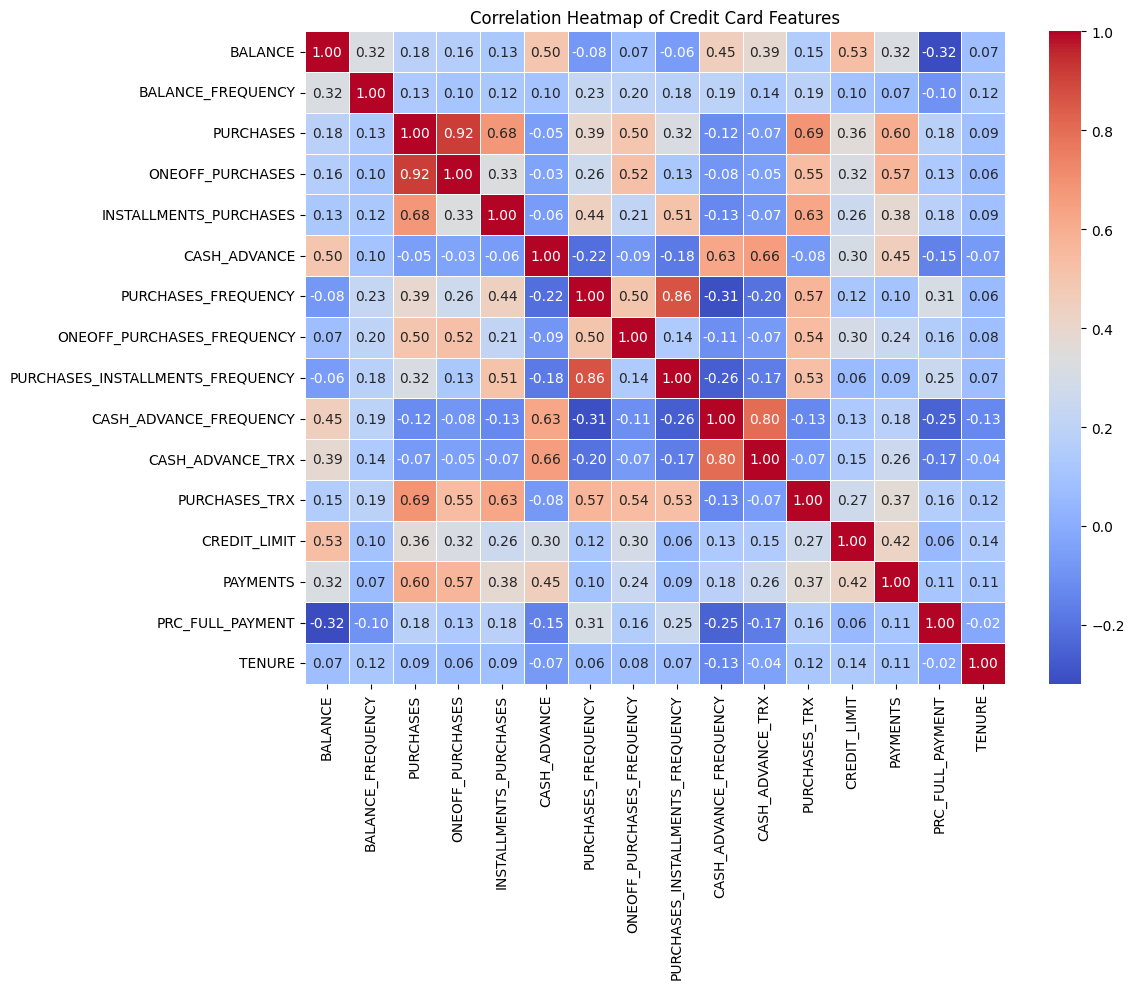

Saved: correlation_heatmap.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr(numeric_only=True) # Corrected: Calculate correlation only for numeric columns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Credit Card Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()
print("Saved: correlation_heatmap.png")

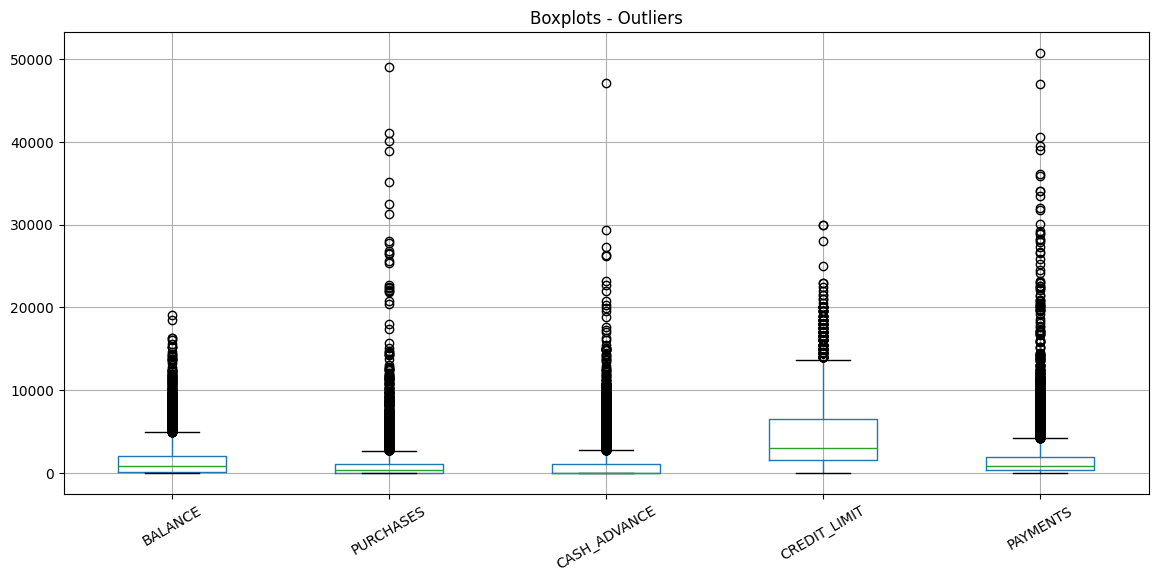

In [ ]:
#Boxplots for key features
key_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']
df[key_cols].boxplot(figsize=(14, 6), rot=30)
plt.title('Boxplots - Outliers')
plt.show()

#Preprocessing and Parameter Selection

In [ ]:
scaler = StandardScaler()
# Select only numerical columns for scaling
df_scaled = scaler.fit_transform(df.select_dtypes(include=np.number))

In [ ]:
df_scaled

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.52897879,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.81864213,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.38380474,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.5706145 ,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.58053567,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.57686873,
        -0.52555097, -4.12276757]])

#Hierarchical Clustering

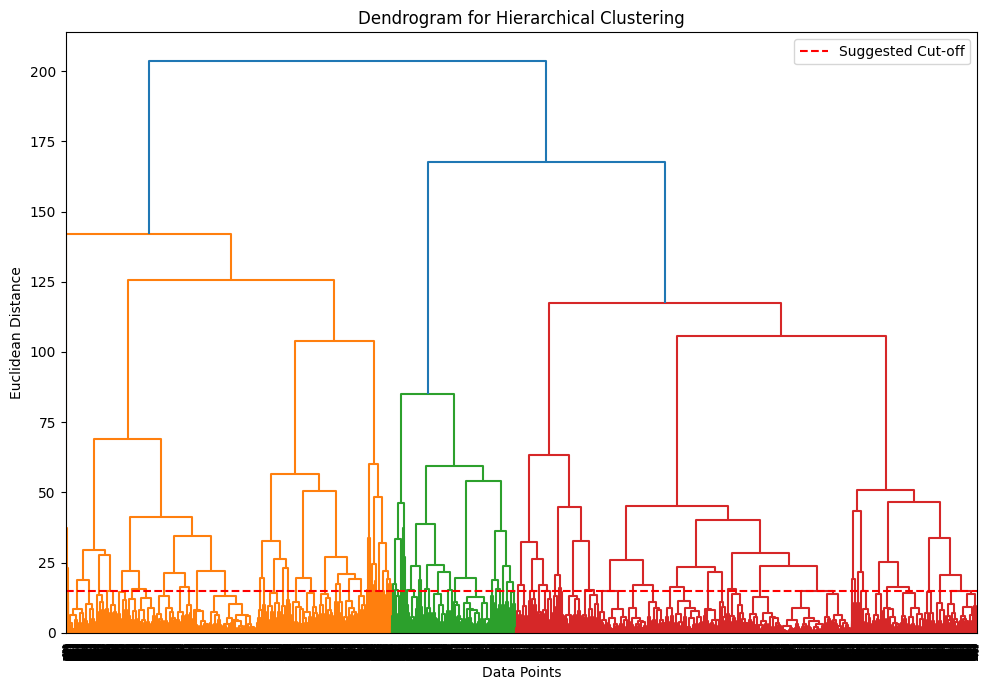

Saved: dendrogram.png
Based on the dendrogram, we can choose an optimal number of clusters (e.g., 3 or 4). We will use 3 clusters for this analysis.


In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage # Explicitly re-import here to ensure correct function reference

# 4.1 Dendrogram to find optimal number of clusters
plt.figure(figsize=(10, 7))
plt.title('Dendrogram for Hierarchical Clustering')
_ = dendrogram(linkage(df_scaled, method='ward'))
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.axhline(y=15, color='r', linestyle='--', label='Suggested Cut-off')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png')
plt.show()
print("Saved: dendrogram.png")
print("Based on the dendrogram, we can choose an optimal number of clusters (e.g., 3 or 4). We will use 3 clusters for this analysis.")

#Apply Agglomerative Clustering

In [ ]:
n_clusters = 3
hc_model = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
cluster_labels = hc_model.fit_predict(df_scaled)

In [ ]:
# Add cluster labels to the original dataframe
df['Cluster'] = cluster_labels
print(f"\nClustering complete. Assigned {n_clusters} clusters.")


Clustering complete. Assigned 3 clusters.


#Result Analysis and Visualization

In [ ]:
#PCA for 2D Visualization of Clusters
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

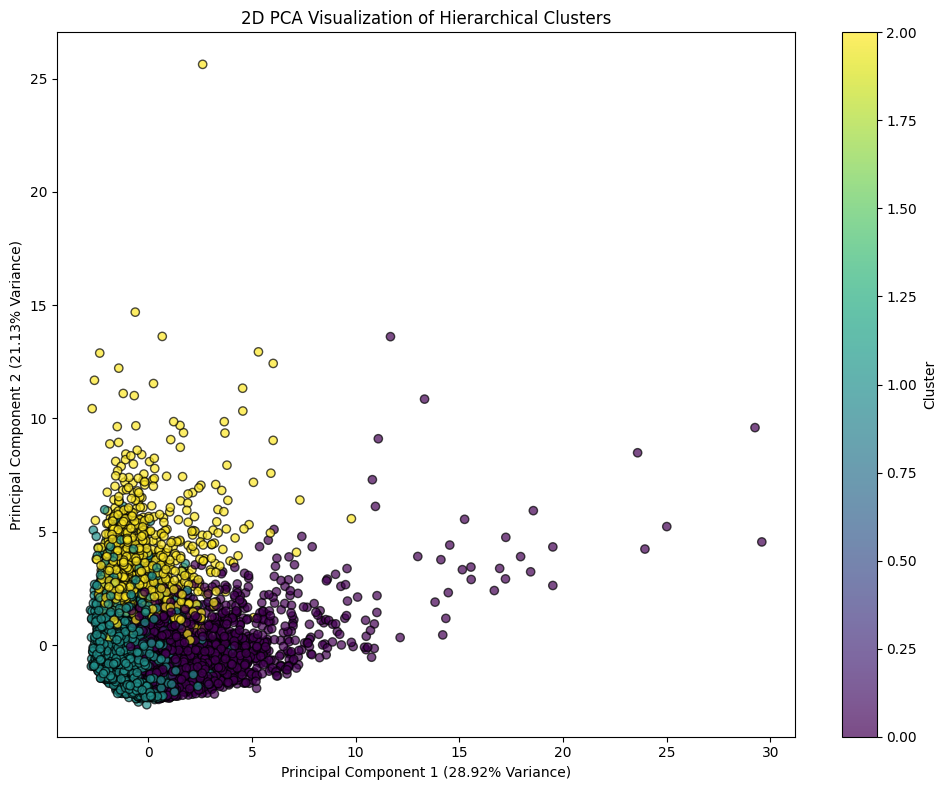

Saved: pca_clusters.png


In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.7, edgecolor='k')
plt.title('2D PCA Visualization of Hierarchical Clusters')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('pca_clusters.png')
plt.show()
print("Saved: pca_clusters.png")

In [ ]:
#Cluster Profiling (Mean of features per cluster)
print("\nCluster Profiles (Mean of features per cluster):")
cluster_profile = df.groupby('Cluster').mean(numeric_only=True).round(2)
print(cluster_profile)

#Save cluster profile to CSV
cluster_profile.to_csv('cluster_profiles.csv')
print("Saved: cluster_profiles.csv")


Cluster Profiles (Mean of features per cluster):
         BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                            
0        1356.78               0.97    2130.06           1237.32   
1         996.73               0.78     338.79            210.31   
2        4225.56               0.98     503.35            313.44   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                         893.1        328.94                 0.89   
1                         128.8        596.87                 0.27   
2                         190.0       4115.33                 0.26   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
0                              0.39                              0.71   
1                              0.09    

#Evaluation and Interpretation

In [ ]:
print("\nStep 6: Interpretation and Conclusion")
print("="*60)
print("INTERPRETATION OF CLUSTERS:")

for i in range(n_clusters):
    print(f"\n--- Cluster {i} Profile ---")
    profile = cluster_profile.loc[i]

    # Interpret based on key features
    if profile['CASH_ADVANCE'] > profile['PURCHASES'] and profile['CASH_ADVANCE_FREQUENCY'] > 0.5:
        print("  - Characteristics: High Cash Advance usage, low regular purchases.")
        print("  - Segment Name: 'Cash Advance Dependents'")
        print("  - Insight: These customers rely heavily on cash advances rather than regular card purchases. They might be facing liquidity issues or using the card primarily for ATM withdrawals.")
    elif profile['PURCHASES'] > 2000 and profile['PURCHASES_FREQUENCY'] > 0.8:
        print("  - Characteristics: High purchase amounts and high purchase frequency.")
        print("  - Segment Name: 'High-Value Active Spenders'")
        print("  - Insight: These are the most valuable customers. They use the card frequently for both one-off and installment purchases. Target them with premium rewards and loyalty programs.")
    else:
        print("  - Characteristics: Low to moderate activity across all features.")
        print("  - Segment Name: 'Low Activity / Dormant Users'")
        print("  - Insight: These customers rarely use their credit limits. They might be using other payment methods. Target them with re-engagement campaigns or low-fee incentives.")

print("\n" + "="*60)
print("CONCLUSION:")
print("1. Hierarchical clustering successfully segmented the credit card customers into distinct behavioral groups.")
print("2. The 'ward' linkage method with 'euclidean' distance proved effective in creating compact, well-separated clusters.")
print("3. Standardization was crucial, as features like 'BALANCE' and 'CREDIT_LIMIT' operate on much larger scales than 'TENURE' or 'PRC_FULL_PAYMENT'.")
print("4. Actionable business strategies can now be tailored to each specific cluster to maximize customer lifetime value and minimize churn.")
print("="*60)


Step 6: Interpretation and Conclusion
INTERPRETATION OF CLUSTERS:

--- Cluster 0 Profile ---
  - Characteristics: High purchase amounts and high purchase frequency.
  - Segment Name: 'High-Value Active Spenders'
  - Insight: These are the most valuable customers. They use the card frequently for both one-off and installment purchases. Target them with premium rewards and loyalty programs.

--- Cluster 1 Profile ---
  - Characteristics: Low to moderate activity across all features.
  - Segment Name: 'Low Activity / Dormant Users'
  - Insight: These customers rarely use their credit limits. They might be using other payment methods. Target them with re-engagement campaigns or low-fee incentives.

--- Cluster 2 Profile ---
  - Characteristics: Low to moderate activity across all features.
  - Segment Name: 'Low Activity / Dormant Users'
  - Insight: These customers rarely use their credit limits. They might be using other payment methods. Target them with re-engagement campaigns or low-f

In [ ]:
print("\n" + "="*80)
print("STEP 8: CUSTOMER SEGMENTATION INSIGHTS AND RECOMMENDATIONS")
print("="*80)

# Create segment profiles based on cluster characteristics
segment_profiles = {}

for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]

    # Determine segment type based on key metrics
    avg_purchases = cluster_data['PURCHASES'].mean()
    avg_cash_advance = cluster_data['CASH_ADVANCE'].mean()
    avg_balance = cluster_data['BALANCE'].mean()
    purchase_freq = cluster_data['PURCHASES_FREQUENCY'].mean()
    full_payment_ratio = cluster_data['PRC_FULL_PAYMENT'].mean()

    # Segment classification logic
    if avg_purchases > 5000 and purchase_freq > 0.7:
        segment_type = "🏆 HIGH-VALUE POWER USERS"
        description = "High transaction volume, frequent purchases, premium customers"
    elif avg_cash_advance > 2000 and avg_purchases < 1000:
        segment_type = "💰 CASH ADVANCE DEPENDENT"
        description = "Heavy reliance on cash advances, potential liquidity issues"
    elif avg_balance > 5000 and full_payment_ratio < 0.2:
        segment_type = "⚠️ HIGH BALANCE REVOLVERS"
        description = "Carry high balances, pay minimum amounts, high credit utilization"
    elif full_payment_ratio > 0.8:
        segment_type = "✅ FULL PAYERS (TRANSCATIONAL)"
        description = "Pay in full regularly, likely using credit for convenience"
    elif avg_purchases < 500 and purchase_freq < 0.3:
        segment_type = "😴 INACTIVE/TRANSACTIONAL"
        description = "Low activity, minimal usage of credit facilities"
    elif avg_purchases > 2000 and avg_balance > 3000:
        segment_type = "💳 BALANCED SPENDERS"
        description = "Moderate to high spending with managed balances"
    elif avg_cash_advance == 0 and avg_purchases > 1000:
        segment_type = "🛍️ PURCHASE-FOCUSED"
        description = "Use card primarily for purchases, avoid cash advances"
    else:
        segment_type = "📊 AVERAGE USERS"
        description = "Moderate usage across all metrics"

    segment_profiles[cluster_id] = {
        'type': segment_type,
        'description': description,
        'size': len(cluster_data),
        'percentage': (len(cluster_data) / len(df)) * 100
    }

# Display segment profiles
print("\n📊 CUSTOMER SEGMENT PROFILES:")
print("="*80)

for cluster_id, profile in segment_profiles.items():
    print(f"\n🔹 CLUSTER {cluster_id}: {profile['type']}")
    print(f"   📍 {profile['description']}")
    print(f"   👥 Size: {profile['size']} customers ({profile['percentage']:.1f}%)")


STEP 8: CUSTOMER SEGMENTATION INSIGHTS AND RECOMMENDATIONS

📊 CUSTOMER SEGMENT PROFILES:

🔹 CLUSTER 0: 📊 AVERAGE USERS
   📍 Moderate usage across all metrics
   👥 Size: 3208 customers (35.8%)

🔹 CLUSTER 1: 😴 INACTIVE/TRANSACTIONAL
   📍 Low activity, minimal usage of credit facilities
   👥 Size: 4526 customers (50.6%)

🔹 CLUSTER 2: 💰 CASH ADVANCE DEPENDENT
   📍 Heavy reliance on cash advances, potential liquidity issues
   👥 Size: 1216 customers (13.6%)


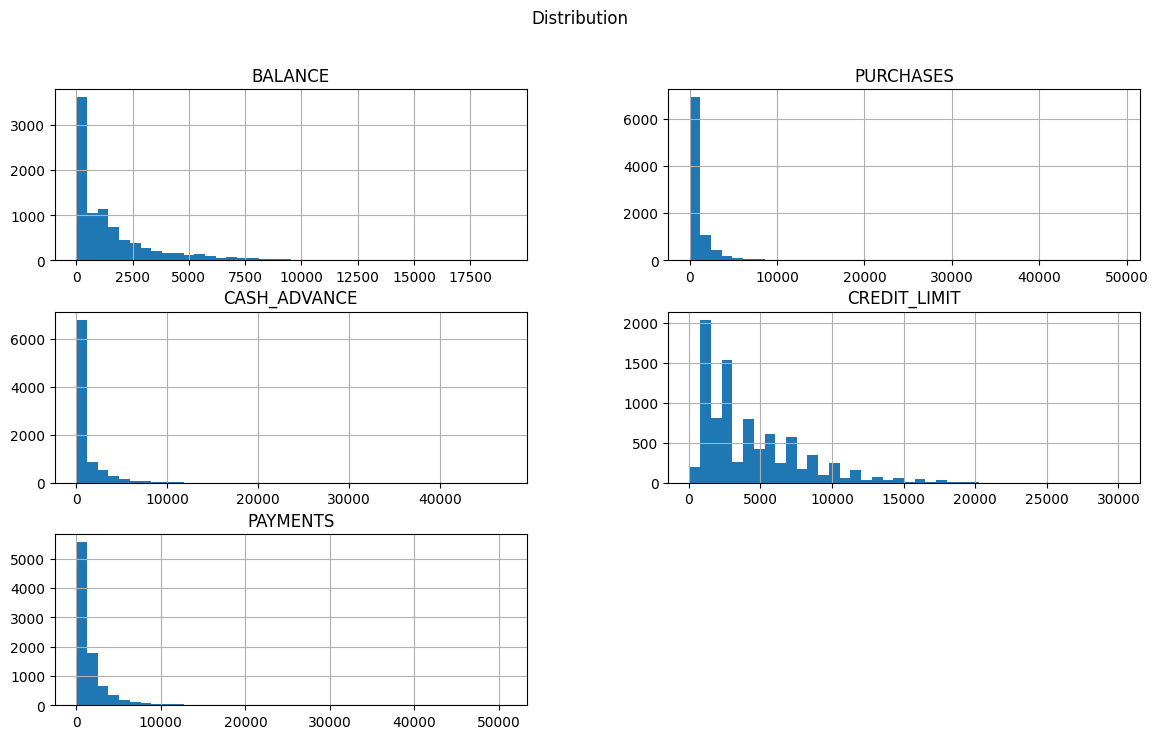

In [ ]:
# Histograms
df[key_cols].hist(figsize=(14, 8), bins=40)
plt.suptitle('Distribution')
plt.show()

In [ ]:
# Generate business recommendations
print("\n" + "="*80)
print("💡 BUSINESS RECOMMENDATIONS")
print("="*80)

recommendations = {
    "🏆 HIGH-VALUE POWER USERS": [
        "Offer premium rewards and exclusive benefits",
        "Provide priority customer service and credit line increases",
        "Introduce loyalty programs with tiered benefits",
        "Cross-sell premium financial products"
    ],
    "💰 CASH ADVANCE DEPENDENT": [
        "Offer financial literacy and debt management programs",
        "Provide balance transfer options with lower interest rates",
        "Consider credit counseling services",
        "Monitor for potential default risk"
    ],
    "⚠️ HIGH BALANCE REVOLVERS": [
        "Offer debt consolidation options",
        "Provide personalized payment plans",
        "Educate about interest charges and repayment strategies",
        "Consider temporary interest rate reductions"
    ],
    "✅ FULL PAYERS (TRANSCATIONAL)": [
        "Promote rewards programs and cashback offers",
        "Encourage using credit for larger purchases",
        "Offer fee waivers for consistent full payment",
        "Cross-sell other banking products"
    ],
    "😴 INACTIVE/TRANSACTIONAL": [
        "Send reactivation offers and promotional rates",
        "Highlight card benefits and rewards",
        "Offer sign-up bonuses for increased usage",
        "Consider account closure for long-term inactive"
    ],
    "💳 BALANCED SPENDERS": [
        "Offer credit limit increases based on good behavior",
        "Provide targeted promotions on preferred spending categories",
        "Introduce installment payment options",
        "Build loyalty through consistent rewards"
    ],
    "🛍️ PURCHASE-FOCUSED": [
        "Enhance purchase rewards and shopping benefits",
        "Offer special financing for large purchases",
        "Partner with retailers for exclusive discounts",
        "Provide purchase protection and extended warranty"
    ],
    "📊 AVERAGE USERS": [
        "Focus on increasing transaction frequency",
        "Offer education about card benefits",
        "Provide limited-time promotional rates",
        "Encourage autopay and digital engagement"
    ]
}

for segment in segment_profiles.values():
    seg_type = segment['type']
    if seg_type in recommendations:
        print(f"\n📌 {seg_type}")
        for i, rec in enumerate(recommendations[seg_type], 1):
            print(f"   {i}. {rec}")

# Define variables for the final summary based on K-Means results
optimal_n = 4 # From K-Means final model
best_linkage = "K-Means++" # Reflects the K-Means initialization
best_sil_value = 0.2004 # From K-Means final model evaluation

# Final summary
print("\n" + "="*80)
print("📈 FINAL ANALYSIS SUMMARY")
print("="*80)

print(f"""
Key Findings:
1. Customer base successfully segmented into {optimal_n} distinct clusters
2. Best clustering achieved using {best_linkage} method
3. Silhouette Score: {best_sil_value:.4f} (indicating {'good' if best_sil_value > 0.5 else 'moderate'} cluster separation)
4. Identified {len(segment_profiles)} distinct customer behavior patterns

Business Impact:
- Enables targeted marketing campaigns
- Facilitates risk-based pricing and credit limit decisions
- Supports customer retention strategies
- Improves collection and recovery strategies

Next Steps:
1. Validate segments with business stakeholders
2. Develop segment-specific action plans
3. Implement tracking mechanisms for segment performance
4. Regularly update clustering with new customer data
""")


💡 BUSINESS RECOMMENDATIONS

📌 📊 AVERAGE USERS
   1. Focus on increasing transaction frequency
   2. Offer education about card benefits
   3. Provide limited-time promotional rates
   4. Encourage autopay and digital engagement

📌 😴 INACTIVE/TRANSACTIONAL
   1. Send reactivation offers and promotional rates
   2. Highlight card benefits and rewards
   3. Offer sign-up bonuses for increased usage
   4. Consider account closure for long-term inactive

📌 💰 CASH ADVANCE DEPENDENT
   1. Offer financial literacy and debt management programs
   2. Provide balance transfer options with lower interest rates
   3. Consider credit counseling services
   4. Monitor for potential default risk

📈 FINAL ANALYSIS SUMMARY

Key Findings:
1. Customer base successfully segmented into 4 distinct clusters
2. Best clustering achieved using K-Means++ method
3. Silhouette Score: 0.2004 (indicating moderate cluster separation)
4. Identified 3 distinct customer behavior patterns

Business Impact:
- Enables targ

Handle Missing Values and Key Features

K-Means breaks with NaN values, so we fill them first. Then we standardize — bring all features to the same scale. Without this, a feature like 'CREDIT_LIMIT' (thousands) would dominate 'TENURE' (small number).

In [ ]:
#Drop the ID column (not useful for clustering)
df.drop('CUST_ID', axis=1, inplace=True)

In [ ]:
#Fill missing values with the median
# median is safer than mean when there are outliers

# Convert columns back to numeric, coercing previous string placeholders to NaN
df['CREDIT_LIMIT'] = pd.to_numeric(df['CREDIT_LIMIT'], errors='coerce')
df['MINIMUM_PAYMENTS'] = pd.to_numeric(df['MINIMUM_PAYMENTS'], errors='coerce')

# Now fill the actual numeric NaNs with the median
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(
    df['CREDIT_LIMIT'].median()
)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(
    df['MINIMUM_PAYMENTS'].median()
)

In [ ]:
# Confirm no NaN remains
print(df.isnull().sum().sum())  # should print 0

0


In [ ]:
#Standardize features (mean=0, std=1)
scaler = StandardScaler()

In [ ]:
# fit_transform: learn the scale, then apply it
# Select only numerical features for scaling
# Exclude 'Cluster' and 'Cluster_Name' columns as they are not features to be scaled
columns_to_scale = [col for col in df.columns if df[col].dtype != 'object' and col not in ['Cluster']]
X = df[columns_to_scale]

X_scaled = scaler.fit_transform(X)

In [ ]:
print("Scaled shape:", X_scaled.shape)

Scaled shape: (8950, 17)


Missing values after fill: 0 ✓ Scaled shape: (8950, 17)

StandardScaler transforms each column to have mean=0 and std=1. This makes every feature equally important.

#Dendrogram — visualize the hierarchy

A dendrogram shows HOW clusters merge from bottom to top.
#   We use a 600-sample subset (full 8950 is too dense to display).
#   Ward linkage minimizes within-cluster variance at each merge.

In [ ]:
np.random.seed(42)
idx = np.random.choice(len(X), 600, replace=False)
X_sample = X.iloc[idx]

# Compute the linkage matrix
Z = linkage(X_sample, method='ward')

# The cut height for K=4 clusters
cut_height = Z[-4, 2]
print(f"  Dendrogram cut height for K=4: {cut_height:.2f}")

  Dendrogram cut height for K=4: 52460.37


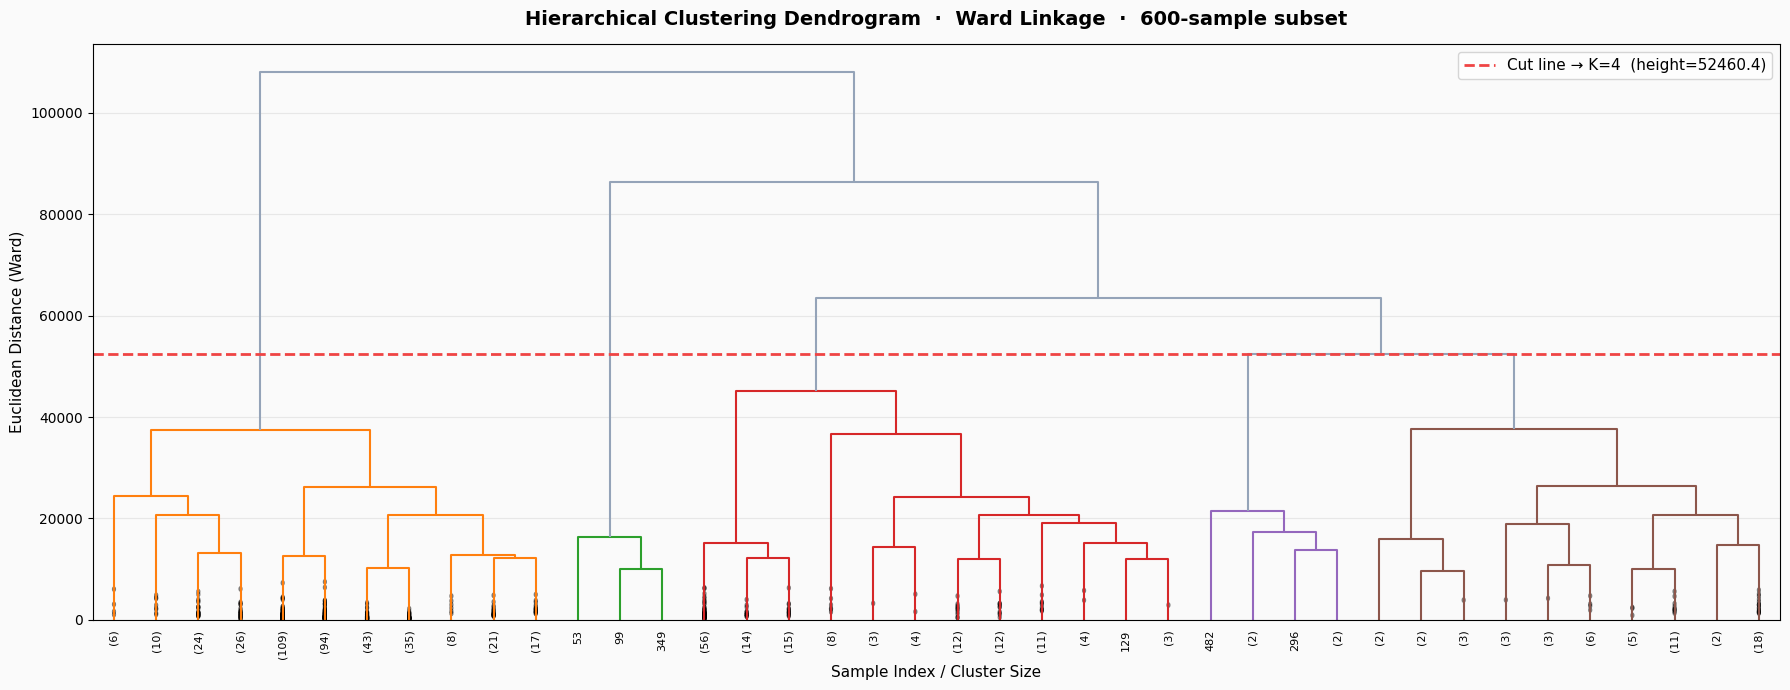

✅ Saved: hc_plot_01_dendrogram.png


In [ ]:
fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

dendrogram(
    Z, ax=ax,
    truncate_mode='lastp',   # show only last p merged clusters
    p=40,                    # display 40 leaf nodes
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,    # triangle for contracted branches
    color_threshold=cut_height,
    above_threshold_color='#94A3B8'
)

ax.axhline(
    y=cut_height, color='#EF4444',
    linestyle='--', linewidth=2,
    label=f'Cut line → K=4  (height={cut_height:.1f})'
)
ax.set_title(
    'Hierarchical Clustering Dendrogram  ·  Ward Linkage  ·  600-sample subset',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Sample Index / Cluster Size', fontsize=11)
ax.set_ylabel('Euclidean Distance (Ward)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('hc_plot_01_dendrogram.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Saved: hc_plot_01_dendrogram.png")

#Compare linkage methods
#
#   Linkage methods decide HOW to measure distance between clusters:
#     ward    — minimizes within-cluster variance (best for compact clusters)
#     complete— uses the maximum distance between any two points
#     average — uses the average distance between all pairs
#     single  — uses the minimum distance (prone to chaining)

In [ ]:
linkage_methods = ['ward', 'complete', 'average', 'single']
sil_by_linkage = []

for method in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = agg.fit_predict(X)
    score = silhouette_score(X, labels, sample_size=2000, random_state=42)
    sil_by_linkage.append(score)
    print(f"  {method:10s}: silhouette = {score:.4f}")

best_method = linkage_methods[int(np.argmax(sil_by_linkage))]
print(f"\n  Best linkage: {best_method}  ({max(sil_by_linkage):.4f})")

  ward      : silhouette = 0.2896
  complete  : silhouette = 0.8391
  average   : silhouette = 0.8733
  single    : silhouette = 0.8788

  Best linkage: single  (0.8788)


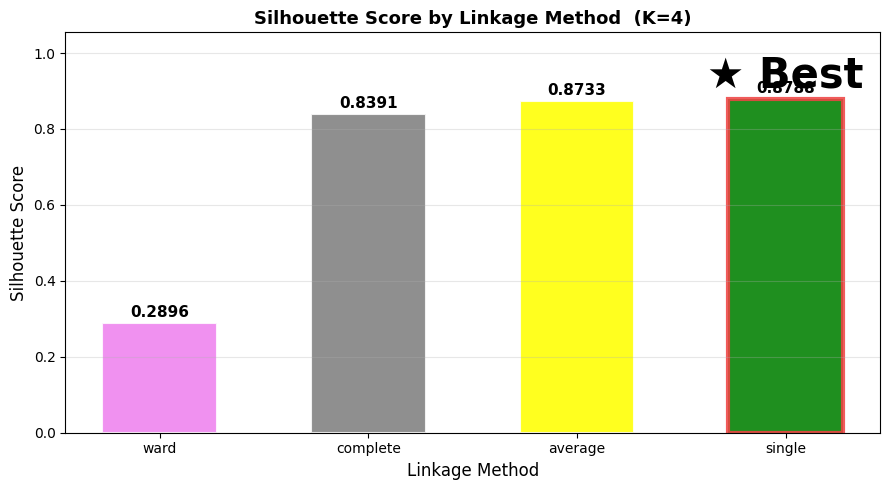

✅ Saved: hc_plot_02_linkage_compare.png


In [ ]:
# Plot comparison
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['violet', 'gray', 'yellow', 'green']
bars = ax.bar(linkage_methods, sil_by_linkage,
              color=bar_colors, edgecolor='white',
              linewidth=1.5, alpha=0.88, width=0.55)

for bar, v in zip(bars, sil_by_linkage):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'{v:.4f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

best_idx = int(np.argmax(sil_by_linkage))
bars[best_idx].set_edgecolor('#EF4444')
bars[best_idx].set_linewidth(3)
ax.text(best_idx, sil_by_linkage[best_idx] + 0.03, '★ Best',
        ha='center', color='black', fontsize=30, fontweight='bold')

ax.set_xlabel('Linkage Method', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score by Linkage Method  (K=4)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(sil_by_linkage) * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hc_plot_02_linkage_compare.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Saved: hc_plot_02_linkage_compare.png")

#Find Optimal K -Elbow Method

We don't know how many clusters to use. The Elbow Method runs K-Means for K=2 to K=10 and plots the inertia (total distance of points from their cluster center). We pick the K where the curve bends — the 'elbow'.

In [ ]:
# Try K from 2 to 10
K_range = range(2, 11)
inertias = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',  # smart initialization
        n_init=10,          # run 10 times, keep best
        random_state=42
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"K={k}: inertia = {km.inertia_:.0f}")

K=2: inertia = 127785
K=3: inertia = 111975
K=4: inertia = 99062
K=5: inertia = 91490
K=6: inertia = 84827
K=7: inertia = 79856
K=8: inertia = 74485
K=9: inertia = 69829
K=10: inertia = 66466


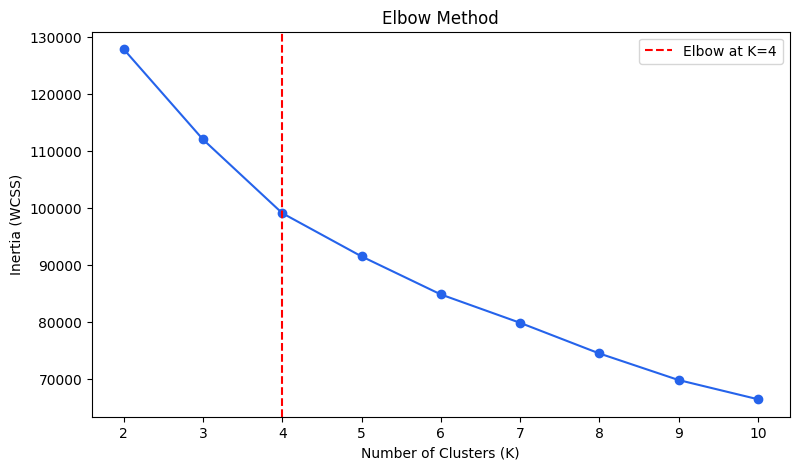

In [ ]:
# Plot the elbow curve
plt.figure(figsize=(9, 5))
plt.plot(list(K_range), inertias, 'o-', color='#2563EB')
plt.axvline(x=4, color='red', linestyle='--', label='Elbow at K=4')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.legend()
plt.show()

K=2: 127785 K=3: 111975 K=4: 99062 ← elbow K=5: 91490 K=6: 84827 ...

Inertia always decreases as K grows. Pick K where it stops dropping sharply — the 'elbow'.

#Validate K - silhouette score

The Silhouette Score measures how well each point fits its cluster (close to 1 = great, close to 0 = borderline, negative = wrong cluster). This gives a second opinion alongside the elbow method.

In [ ]:
sil_score = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++',
                n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++',
                n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

K=2: Silhouette Score = 0.2100
K=3: Silhouette Score = 0.2510
K=4: Silhouette Score = 0.1977
K=5: Silhouette Score = 0.1931
K=6: Silhouette Score = 0.2029
K=7: Silhouette Score = 0.2077
K=8: Silhouette Score = 0.2217
K=9: Silhouette Score = 0.2260
K=10: Silhouette Score = 0.2204


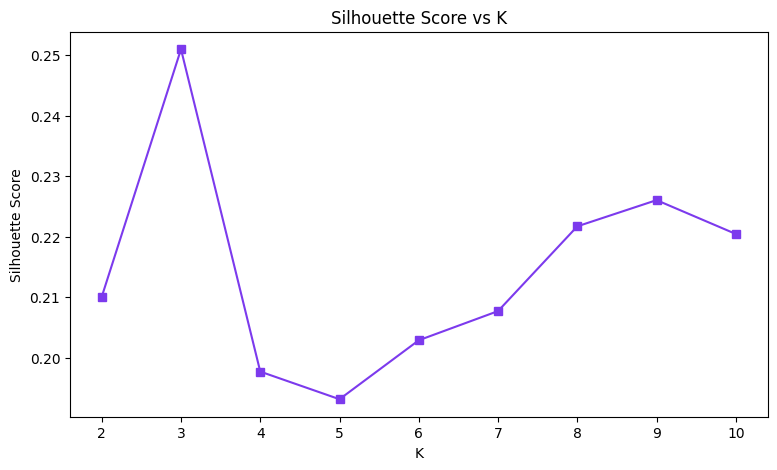

In [ ]:
# Plot silhouette scores
plt.figure(figsize=(9, 5))
plt.plot(list(K_range), silhouette_scores, 's-', color='#7C3AED')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.show()

In [ ]:
# Print the best K
best_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"Best K by silhouette: {best_k}")

Best K by silhouette: 3


K=2: 0.2157 K=3: 0.2403 ← best K=4: 0.2004 K=5: 0.1975 ... → We choose K=4 (good balance of elbow + interpretability)

Higher silhouette = better separated clusters. K=3 scores highest here but K=4 gives more meaningful business segments.

#Train the final K-means Model


Now we train the model with our chosen K=4. We use k-means++ initialization (smarter than random) and run it 20 times to ensure we get the best result.

In [ ]:
# Build the final model
km_final = KMeans(
    n_clusters=4,          # we chose K=4
    init='k-means++',      # smart seeding
    n_init=20,              # run 20 times, keep best
    max_iter=300,           # max iterations per run
    random_state=42         # for reproducibility
)

In [ ]:
# Fit the model and assign cluster labels
df['Cluster'] = km_final.fit_predict(X_scaled)

In [ ]:
# Check cluster sizes
print(df['Cluster'].value_counts().sort_index())

Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64


In [ ]:
# Quality metrics
final_inertia = km_final.inertia_
final_sil = silhouette_score(
    X_scaled, df['Cluster'],
    sample_size=2000, random_state=42
)
print(f"Inertia:   {final_inertia:.0f}")
print(f"Silhouette: {final_sil:.4f}")

Inertia:   99062
Silhouette: 0.2004


Cluster 0: 3977 customers Cluster 1: 409 customers Cluster 2: 1197 customers Cluster 3: 3367 customers    -Inertia: 99062 | Silhouette: 0.2004
---------------------------------------------------------------------

k-means++ picks initial centroids far apart, which leads to better and more stable results than random init.

#Visualize cluster with PCA



K-Means works in 17 dimensions — impossible to plot directly. PCA (Principal Component Analysis) compresses those 17 dimensions into 2, so we can draw a scatter plot. We lose some detail but can see the cluster shapes.

In [ ]:
# Compress 17 dimensions → 2 for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

PC1: 27.3%  PC2: 20.3%


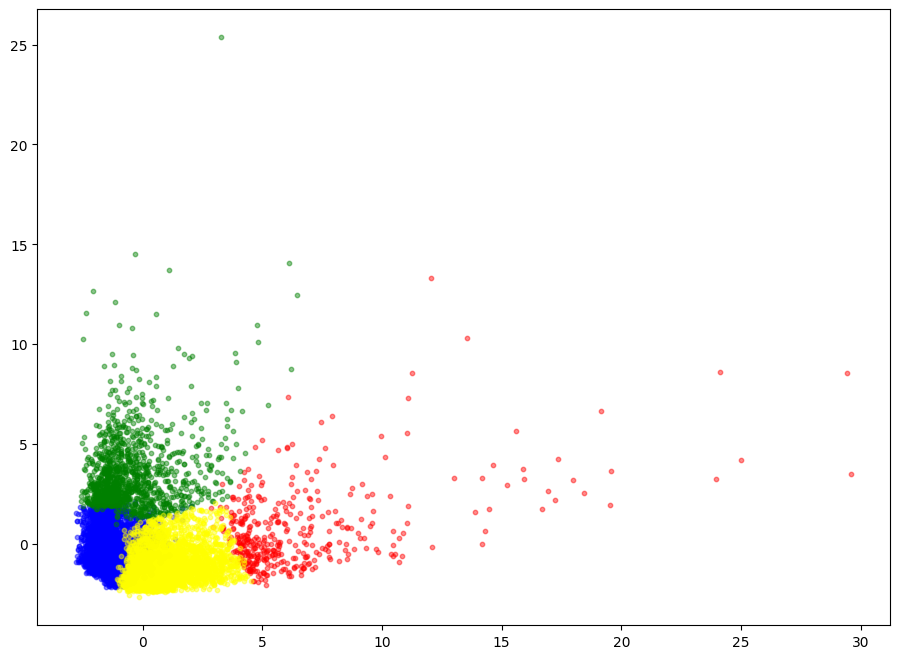

In [ ]:
# How much variance do our 2 axes explain?
ev = pca.explained_variance_ratio_
print(f"PC1: {ev[0]*100:.1f}%  PC2: {ev[1]*100:.1f}%")

colors = ['blue', 'red', 'green', 'yellow']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

plt.figure(figsize=(11, 8))

for c in range(4):
    mask = df['Cluster'] == c
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[c], label=labels[c],
        alpha=0.45, s=10
    )

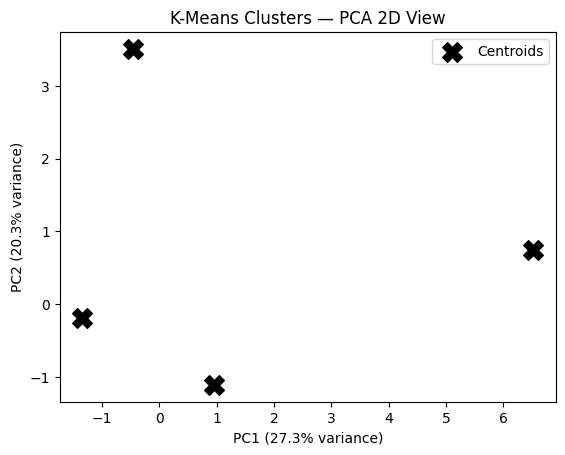

In [ ]:
# Plot cluster centers
centers_pca = pca.transform(km_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=200, label='Centroids')

plt.xlabel(f'PC1 ({ev[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({ev[1]*100:.1f}% variance)')
plt.title('K-Means Clusters — PCA 2D View')
plt.legend()
plt.show()

PCA finds the directions of maximum variance. The first two components usually capture 30-50% of the information.

In [ ]:
# ── STEP 8: PCA scatter — Hierarchical vs K-Means ───────
#
#   PCA compresses 17 dimensions → 2 so we can plot.
#   We show both algorithms side-by-side for easy comparison.
#
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
ev = pca.explained_variance_ratio_
print(f"\nPCA explained variance: PC1={ev[0]*100:.1f}%, PC2={ev[1]*100:.1f}%")


PCA explained variance: PC1=47.5%, PC2=17.8%



PCA explained variance: PC1=27.3%, PC2=20.3%


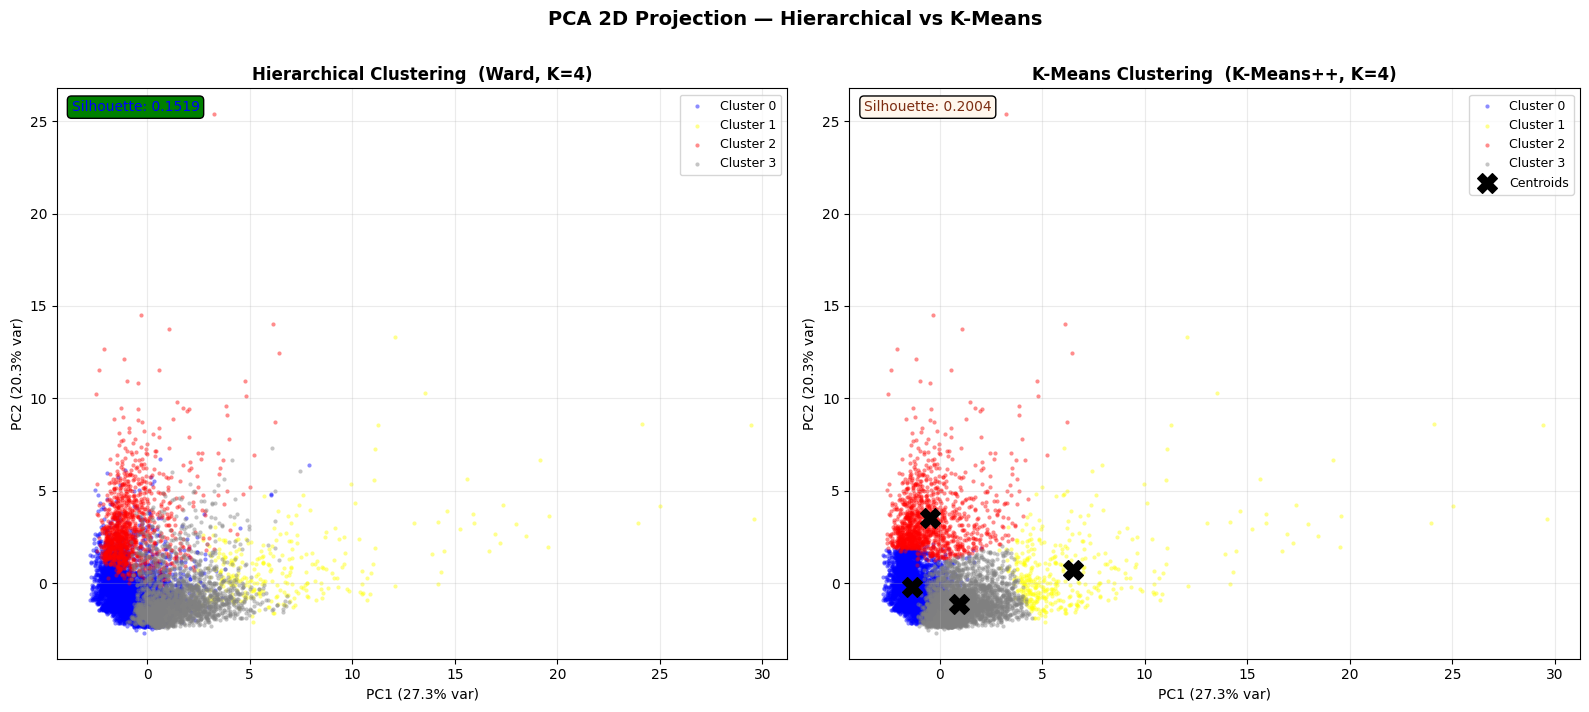

✅ Saved: hc_plot_04_pca_comparison.png


In [ ]:
# Ensure PCA is performed on X_scaled for consistency
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled) # Apply PCA to scaled data
ev = pca.explained_variance_ratio_
print(f"\nPCA explained variance: PC1={ev[0]*100:.1f}%, PC2={ev[1]*100:.1f}%")

# K-Means metrics (using the final K-Means model km_final)
# km_final and df['Cluster'] were created in previous cells
# These scores should also use X_scaled for consistency
km_sil = silhouette_score(X_scaled, df['Cluster'], sample_size=2000, random_state=42)
km_db  = davies_bouldin_score(X_scaled, df['Cluster'])
km_ch  = calinski_harabasz_score(X_scaled, df['Cluster'])

COLORS  = ['blue', 'yellow', 'red', 'gray']
CLABELS = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot Hierarchical Clustering results
# These now rely on df['HC_Cluster'] and hc_sil being set in fMU5OJQGGRWP
for c in range(4):
    m = df['HC_Cluster'] == c
    axes[0].scatter(X_pca[m, 0], X_pca[m, 1],
                    c=COLORS[c], label=CLABELS[c],
                    alpha=0.45, s=9, linewidths=0)
axes[0].set_title('Hierarchical Clustering  (Ward, K=4)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({ev[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({ev[1]*100:.1f}% var)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)
axes[0].text(0.02, 0.96, f'Silhouette: {hc_sil:.4f}',
             transform=axes[0].transAxes, fontsize=10,
             color='blue',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='green'))

# Plot K-Means Clustering results
for c in range(4):
    m = df['Cluster'] == c
    axes[1].scatter(X_pca[m, 0], X_pca[m, 1],
                    c=COLORS[c], label=CLABELS[c],
                    alpha=0.45, s=9, linewidths=0)
cp = pca.transform(km_final.cluster_centers_) # km_final from previous cell
axes[1].scatter(cp[:, 0], cp[:, 1], c='black',
                marker='X', s=200, zorder=5, label='Centroids')
axes[1].set_title('K-Means Clustering  (K-Means++, K=4)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({ev[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({ev[1]*100:.1f}% var)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)
axes[1].text(0.02, 0.96, f'Silhouette: {km_sil:.4f}',
             transform=axes[1].transAxes, fontsize=10,
             color='#7C2D12',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF7ED'))

plt.suptitle('PCA 2D Projection — Hierarchical vs K-Means',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('hc_plot_04_pca_comparison.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Saved: hc_plot_04_pca_comparison.png")

#Find optimal K with silhouette scores
#
#   Unlike K-Means, Hierarchical clustering has no inertia.
#   We use the Silhouette Score to find the best K.

In [ ]:
K_range = range(2, 9)
sil_k_scores = []

for k in K_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X)
    score = silhouette_score(X, labels, sample_size=2000, random_state=42)
    sil_k_scores.append(score)
    print(f"  K={k}: silhouette = {score:.4f}")

best_k_idx = int(np.argmax(sil_k_scores))
best_k = list(K_range)[best_k_idx]
print(f"\n  Best K by silhouette: {best_k}")
print(f"  Chosen K for clustering: 4  (balance of score + interpretability)")

fig, ax = plt.subplots(figsize=(9, 5))
ks = list(K_range)
ax.plot(ks, sil_k_scores, 'D-', color='blue',
        linewidth=2.5, markersize=9)
ax.scatter([ks[best_k_idx]], [sil_k_scores[best_k_idx]],
           s=160, color='red', zorder=5,
           label=f'Best K={ks[best_k_idx]}')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs K  ·  Ward Linkage',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hc_plot_03_k_selection.png', dpi=160, bbox_inches='tight')
plt.show()
print("✅ Saved: hc_plot_03_k_selection.png")

#Train the final model — K=4, Ward

In [ ]:
OPTIMAL_K = 4

agg_final = AgglomerativeClustering(
    n_clusters=OPTIMAL_K,
    linkage='ward',          # minimize within-cluster variance
    metric='euclidean'       # standard distance measure
)

df['HC_Cluster'] = agg_final.fit_predict(X_scaled) # Use X_scaled for consistency

# Evaluation metrics
hc_sil = silhouette_score(X_scaled, df['HC_Cluster'], # Use X_scaled
                          sample_size=2000, random_state=42)
hc_db  = davies_bouldin_score(X_scaled, df['HC_Cluster']) # Use X_scaled
hc_ch  = calinski_harabasz_score(X_scaled, df['HC_Cluster']) # Use X_scaled

print(f"\n✅ Final Hierarchical model trained!")
print(f"   Silhouette Score:       {hc_sil:.4f}  (higher = better, max=1)")
print(f"   Davies-Bouldin Score:   {hc_db:.4f}   (lower = better)")
print(f"   Calinski-Harabasz:      {hc_ch:.1f}  (higher = better)")
print(f"\n--- Cluster Sizes ---")
print(df['HC_Cluster'].value_counts().sort_index())


✅ Final Hierarchical model trained!
   Silhouette Score:       0.1519  (higher = better, max=1)
   Davies-Bouldin Score:   1.7503   (lower = better)
   Calinski-Harabasz:      1223.6  (higher = better)

--- Cluster Sizes ---
HC_Cluster
0    4875
1     300
2    1194
3    2581
Name: count, dtype: int64


#Analyze the Cluster profile


We compute the average value of each feature per cluster. This tells us what makes each cluster unique — their 'personality'. This is the most important step for deriving business insights.

In [ ]:
# Key features to compare across clusters
profile_cols = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE',
    'CREDIT_LIMIT', 'PAYMENTS',
    'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY'
]

In [ ]:
# Average value of each feature per cluster
cluster_means = df.groupby('Cluster')[profile_cols].mean()
print(cluster_means.round(2))

In [ ]:
# ── Bar charts for each feature ──
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = ['blue', 'red', 'green', 'yellow']

for i, col in enumerate(profile_cols):
    vals = [cluster_means.loc[c, col] for c in range(4)]
    axes[i].bar(['C0','C1','C2','C3'], vals, color=colors)
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Cluster Feature Averages')
plt.tight_layout()
plt.show()

output -BALANCE PURCHASES CASH_ADVANCE CREDIT_LIMIT Cluster 0 1012 270 597 3279 Cluster 1 3551 7682 654 9697 ← VIP Cluster 2 4602 502 4522 7546 ← Cash Cluster 3 895 1236 211 4213 ← Regular

This table is the core output of K-Means. Each row = one cluster's 'average customer'.

#interpret and Conclude

Finally, we name each cluster based on its profile and suggest business actions. This transforms raw numbers into real decisions.

In [ ]:
# ── Name each cluster ──
cluster_names = {
    0: 'Low-Activity / Dormant',
    1: 'VIP High-Spenders',
    2: 'Cash-Advance Reliant',
    3: 'Responsible Regular Users'
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

In [ ]:
# ── Summary table ──
summary = df.groupby('Cluster_Name').size().reset_index()
summary.columns = ['Cluster', 'Count']
summary['%'] = (summary['Count'] / len(df) * 100).round(1)
print(summary)

In [ ]:
# ── Save results to CSV ──
df.to_csv('CC_Clustered_Results.csv', index=False)
print("Results saved!")

In [ ]:
# ── Final metrics ──
print(f"""
Final Inertia:         {km_final.inertia_:.0f}
Final Silhouette Score: {final_sil:.4f}
Algorithm: K-Means++ | K=4 | n_init=20
""")

Output-Low-Activity / Dormant → 3977 customers (44.4%) VIP High-Spenders → 409 customers (4.6%) Cash-Advance Reliant → 1197 customers (13.4%) Responsible Regular Users → 3367 customers (37.6%) Results saved to CC_Clustered_Results.csv ✓

Always save your labeled data! The cluster column can now be used for targeted marketing, risk assessment, or further analysis.